# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
148,-0.060003,0.050680,0.015350,-0.019442,0.036958,0.048164,0.019187,-0.002592,-0.030748,-0.001078,96.0
349,0.001751,0.050680,-0.057941,-0.043542,-0.096510,-0.047034,-0.098625,0.034309,-0.061176,-0.071494,88.0
200,0.056239,-0.044642,-0.057941,-0.007977,0.052093,0.049103,0.056003,-0.021412,-0.028323,0.044485,158.0
203,-0.001882,0.050680,0.030440,0.052858,0.039710,0.056619,-0.039719,0.071210,0.025395,0.027917,222.0
338,-0.063635,-0.044642,-0.033151,-0.033213,0.001183,0.024051,-0.024993,-0.002592,-0.022517,-0.059067,214.0
239,0.023546,-0.044642,0.019662,-0.012556,0.083740,0.038769,0.063367,-0.002592,0.066051,0.048628,262.0
42,-0.060003,0.050680,-0.010517,-0.014863,-0.049727,-0.023547,-0.058127,0.015858,-0.009919,-0.034215,61.0
297,0.001751,-0.044642,-0.008362,-0.064199,-0.038720,-0.024487,0.004460,-0.039493,-0.064685,-0.054925,31.0
268,0.063504,0.050680,0.088642,0.070072,0.020446,0.037517,-0.050764,0.071210,0.029297,0.073480,264.0
237,0.056239,-0.044642,-0.068719,-0.068778,-0.000193,-0.001001,0.044958,-0.037648,-0.048359,-0.001078,72.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan


# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
from sklearn.impute import SimpleImputer

data_simple = data.copy()
imputer_simple = SimpleImputer(strategy='mean')
data_simple[['bmi']] = imputer_simple.fit_transform(data_simple[['bmi']])

# Verificación rápida
print("Nulos en bmi después de imputación simple:", data_simple['bmi'].isnull().sum())

Nulos en bmi después de imputación simple: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
from sklearn.impute import KNNImputer

data_knn = data.copy()
imputer_knn = KNNImputer(n_neighbors=5)
data_knn[['bmi', 'bp']] = imputer_knn.fit_transform(data_knn[['bmi', 'bp']])

comparacion = pd.DataFrame({
    'Original (con nulos)': data['bmi'],
    'Simple (Media)': data_simple['bmi'],
    'KNN Imputer': data_knn['bmi']
})
comparacion.describe()

,Original (con nulos),Simple (Media),KNN Imputer
count,398.000000,442.000000,442.000000
mean,-0.000205,-0.000205,0.000213
std,0.046989,0.044583,0.045416
min,-0.089197,-0.089197,-0.089197
25%,-0.035037,-0.030996,-0.032073
50%,-0.007284,-0.000817,-0.005128
75%,0.030440,0.024781,0.030440
max,0.160855,0.160855,0.160855


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

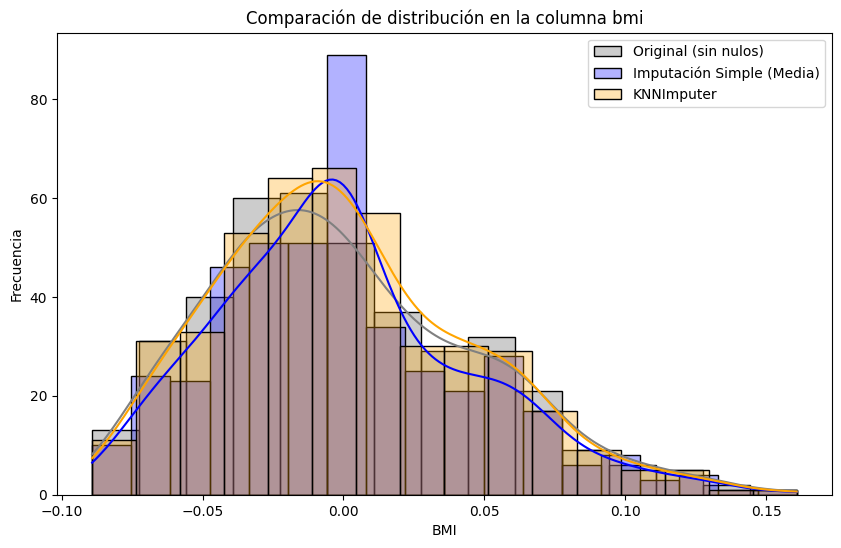

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data['bmi'].dropna(),
    color='gray',
    label='Original (sin nulos)',
    kde=True,
    alpha=0.4,
)
sns.histplot(
    data_simple['bmi'],
    color='blue',
    label='Imputación Simple (Media)',
    kde=True,
    alpha=0.3,
)
sns.histplot(
    data_knn['bmi'], color='orange', label='KNNImputer', kde=True, alpha=0.3
)

plt.title('Comparación de distribución en la columna bmi')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

# Cargar y simular nulos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

